
🚀 TRAINING STARTED...

[Episode 1, Step 0]
State: 36 → Action: RIGHT
Reward: -100
Old Q: 0.00 → New Q: -50.00
----------------------------------------
[Episode 1, Step 1]
State: 36 → Action: DOWN
Reward: -1
Old Q: 0.00 → New Q: -0.50
----------------------------------------
[Episode 1, Step 2]
State: 36 → Action: RIGHT
Reward: -100
Old Q: -50.00 → New Q: -75.00
----------------------------------------
[Episode 1, Step 3]
State: 36 → Action: RIGHT
Reward: -100
Old Q: -75.00 → New Q: -87.50
----------------------------------------
[Episode 1, Step 4]
State: 36 → Action: RIGHT
Reward: -100
Old Q: -87.50 → New Q: -93.75
----------------------------------------
[Episode 1, Step 5]
State: 36 → Action: LEFT
Reward: -1
Old Q: 0.00 → New Q: -0.50
----------------------------------------
[Episode 1, Step 6]
State: 36 → Action: LEFT
Reward: -1
Old Q: -0.50 → New Q: -0.75
----------------------------------------
[Episode 1, Step 7]
State: 36 → Action: LEFT
Reward: -1
Old Q: -0.75 → New Q: -0.88
-

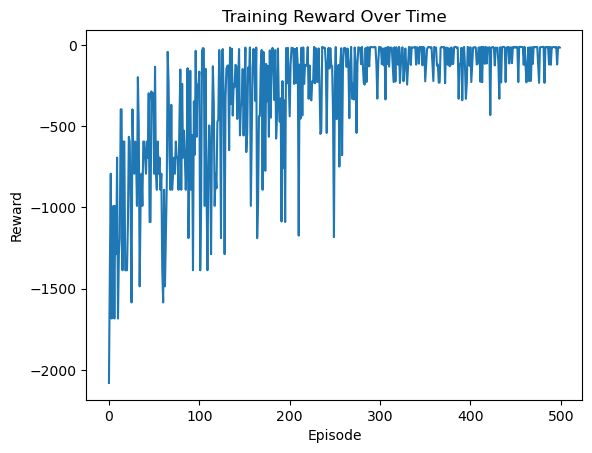


🎮 RUNNING TRAINED AGENT...

Step 0
State: 36 → Action: UP
Reward: -1
------------------------------
Step 1
State: 24 → Action: RIGHT
Reward: -1
------------------------------
Step 2
State: 25 → Action: RIGHT
Reward: -1
------------------------------
Step 3
State: 26 → Action: RIGHT
Reward: -1
------------------------------
Step 4
State: 27 → Action: RIGHT
Reward: -1
------------------------------
Step 5
State: 28 → Action: RIGHT
Reward: -1
------------------------------
Step 6
State: 29 → Action: RIGHT
Reward: -1
------------------------------
Step 7
State: 30 → Action: RIGHT
Reward: -1
------------------------------
Step 8
State: 31 → Action: RIGHT
Reward: -1
------------------------------
Step 9
State: 32 → Action: RIGHT
Reward: -1
------------------------------
Step 10
State: 33 → Action: RIGHT
Reward: -1
------------------------------
Step 11
State: 34 → Action: RIGHT
Reward: -1
------------------------------
Step 12
State: 35 → Action: DOWN
Reward: -1
----------------------------

In [4]:
# ============================================
# Q-Learning CliffWalking (DEEP DEBUG VERSION)
# ============================================

import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import time

# ---------- 1. HYPERPARAMETERS ----------
GAMMA = 0.99
ALPHA = 0.5
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

EPISODES = 500
MAX_STEPS = 100

# ---------- 2. ENV ----------
env = gym.make("CliffWalking-v1")

num_states = env.observation_space.n
num_actions = env.action_space.n

Q = np.zeros((num_states, num_actions))

# ---------- 3. ACTION MEANING ----------
actions_map = {
    0: "UP",
    1: "RIGHT",
    2: "DOWN",
    3: "LEFT"
}

# ---------- 4. POLICY ----------
def select_action(state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state])

# ---------- 5. TRAINING ----------
def train():
    epsilon = EPSILON
    rewards_history = []

    print("\n🚀 TRAINING STARTED...\n")

    for episode in range(EPISODES):
        state, _ = env.reset()
        total_reward = 0

        for step in range(MAX_STEPS):
            action = select_action(state, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q update
            best_next = np.max(Q[next_state])
            old_value = Q[state, action]

            Q[state, action] += ALPHA * (
                reward + GAMMA * best_next - Q[state, action]
            )

            # DEBUG (only first few episodes)
            if episode < 2:
                print(f"[Episode {episode+1}, Step {step}]")
                print(f"State: {state} → Action: {actions_map[action]}")
                print(f"Reward: {reward}")
                print(f"Old Q: {old_value:.2f} → New Q: {Q[state, action]:.2f}")
                print("-" * 40)

            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        rewards_history.append(total_reward)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1} | Reward: {total_reward} | Epsilon: {epsilon:.3f}")

    return rewards_history

# ---------- 6. TRAIN ----------
rewards = train()

# ---------- 7. GRAPH ----------
plt.figure()
plt.plot(rewards)
plt.title("Training Reward Over Time")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# ---------- 8. LIVE GAME ----------
def play_with_visual():
    print("\n🎮 RUNNING TRAINED AGENT...\n")

    env_render = gym.make("CliffWalking-v1", render_mode="human")
    state, _ = env_render.reset()

    total_reward = 0

    for step in range(MAX_STEPS):
        action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env_render.step(action)

        print(f"Step {step}")
        print(f"State: {state} → Action: {actions_map[action]}")
        print(f"Reward: {reward}")
        print("-" * 30)

        state = next_state
        total_reward += reward

        time.sleep(0.4)

        if terminated or truncated:
            print("\n🏁 Episode Finished!")
            break

    env_render.close()
    print(f"\nFinal Reward: {total_reward}")

# ---------- 9. PLAY ----------
play_with_visual()

# ---------- 10. FINAL Q TABLE SAMPLE ----------
print("\n🔍 Sample Q-values:")
print("State 36:", Q[36])
print("State 35:", Q[35])

In [5]:
env = gym.make("CliffWalking-v1", render_mode="ansi")

state, _ = env.reset()

for step in range(20):
    print(env.render())

    action = np.argmax(Q[state])
    state, reward, terminated, truncated, _ = env.step(action)

    if terminated or truncated:
        print("🏁 Finished")
        break

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  x  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  x  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  x  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  x  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  x  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


o  o  